In [ ]:
import marimo as mo

# BTC Polymarket Fair Value from Spot and Futures

This example prices BTC Polymarket touch markets with a simple GBM barrier
model. Inputs are a committed snapshot generated by:

```bash
cd infrastructure/pipelines/polymarket
../../.venv/bin/python scripts/run_btc_fair_value_example.py --as-of 2026-05-28
```

The notebook does not make live API calls. It reads:
- Polymarket YES prices from the Polymarket pipeline cache snapshot
- BTC spot, 1M futures, and 3M futures from the yfinance export step

Model caveat: this is a research approximation, not a production pricing
model or trading recommendation.

In [ ]:
import json
import math
import pathlib

import matplotlib
matplotlib.use("Agg")
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "axes.grid": True,
    "grid.color": "#21262d",
    "grid.alpha": 0.6,
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
    "savefig.facecolor": "#0d1117",
    "savefig.edgecolor": "#0d1117",
})

In [ ]:
DATA_DIR = pathlib.Path(__file__).resolve().parent.parent / "data" / "btc_polymarket_fair_value"
_required = [
    "btc_polymarket_markets.csv",
    "btc_polymarket_prices.csv",
    "btc_spot_futures.csv",
    "btc_futures_contracts.csv",
    "snapshot.json",
]
_missing = [name for name in _required if not (DATA_DIR / name).exists()]

if _missing:
    markets = pd.DataFrame()
    poly_prices = pd.DataFrame()
    btc_prices = pd.DataFrame()
    futures_contracts = pd.DataFrame()
    snapshot = {}
    _data_status = mo.callout(
        mo.md(
            "Missing snapshot files: "
            + ", ".join(f"`{name}`" for name in _missing)
            + "\n\nRun `scripts/run_btc_fair_value_example.py` from the Polymarket pipeline."
        ),
        kind="warn",
    )
else:
    markets = pd.read_csv(DATA_DIR / "btc_polymarket_markets.csv")
    markets["end_date"] = pd.to_datetime(markets["end_date"], utc=True).dt.tz_convert(None)

    poly_prices = pd.read_csv(DATA_DIR / "btc_polymarket_prices.csv", parse_dates=["date"])
    btc_prices = pd.read_csv(DATA_DIR / "btc_spot_futures.csv", parse_dates=["date"]).set_index("date")
    futures_contracts = pd.read_csv(DATA_DIR / "btc_futures_contracts.csv")
    futures_contracts["contract_month_end"] = pd.to_datetime(futures_contracts["contract_month_end"])

    snapshot = json.loads((DATA_DIR / "snapshot.json").read_text())
    _data_status = mo.md(
        f"Snapshot generated **{snapshot.get('generated_at_utc', 'unknown')}**  \n"
        f"Markets: **{len(markets)}**  |  Polymarket rows: **{len(poly_prices)}**  |  "
        f"BTC price rows: **{len(btc_prices)}**"
    )

_data_status

Snapshot generated **2026-05-28T04:11:01.112187+00:00**  
Markets: **5**  |  Polymarket rows: **155**  |  BTC price rows: **57**

In [ ]:
if btc_prices.empty or markets.empty:
    _overview = mo.callout(mo.md("Snapshot data is unavailable."), kind="warn")
else:
    _contract_bits = []
    for _row in futures_contracts.itertuples():
        _contract_bits.append(f"{_row.label}: `{_row.symbol}` through {_row.contract_month_end.date()}")
    _overview = mo.vstack([
        mo.md(
            f"BTC data range: **{btc_prices.index.min().date()}** to "
            f"**{btc_prices.index.max().date()}**"
        ),
        mo.md("Futures contracts: " + " | ".join(_contract_bits)),
        markets[["label", "event_type", "target", "latest_polymarket_prob", "end_date"]],
    ])
_overview

,label,event_type,target,latest_polymarket_prob,end_date
0,Reach $90k,reach,90000.0,0.535,2027-01-01 05:00:00
1,Reach $100k,reach,100000.0,0.325,2027-01-01 05:00:00
2,Reach $110k,reach,110000.0,0.195,2027-01-01 05:00:00
3,Reach $120k,reach,120000.0,0.155,2027-01-01 05:00:00
4,Dip to $50k,dip,50000.0,0.395,2027-01-01 05:00:00


In [ ]:
VOL_WINDOW = 30
MIN_VOL_OBS = 15
TRADING_DAYS = 365.0

def norm_cdf(x):
    return 0.5 * math.erfc(-x / math.sqrt(2.0))

def clamp_prob(x):
    if not np.isfinite(x):
        return np.nan
    return float(min(1.0, max(0.0, x)))

def up_touch_probability(spot, target, years, carry_rate, vol):
    if spot <= 0 or target <= 0 or years <= 0 or vol <= 0:
        return np.nan
    if target <= spot:
        return 1.0
    distance = math.log(target / spot)
    mu = carry_rate - 0.5 * vol * vol
    denom = vol * math.sqrt(years)
    term_1 = norm_cdf((-distance + mu * years) / denom)
    exponent = 2.0 * mu * distance / (vol * vol)
    exponent = min(60.0, max(-60.0, exponent))
    term_2 = math.exp(exponent) * norm_cdf((-distance - mu * years) / denom)
    return clamp_prob(term_1 + term_2)

def touch_probability(event_type, spot, target, years, carry_rate, vol):
    if event_type == "reach":
        return up_touch_probability(spot, target, years, carry_rate, vol)
    if event_type == "dip":
        if target >= spot:
            return 1.0
        distance = math.log(spot / target)
        mu = -(carry_rate - 0.5 * vol * vol)
        denom = vol * math.sqrt(years)
        term_1 = norm_cdf((-distance + mu * years) / denom)
        exponent = 2.0 * mu * distance / (vol * vol)
        exponent = min(60.0, max(-60.0, exponent))
        term_2 = math.exp(exponent) * norm_cdf((-distance - mu * years) / denom)
        return clamp_prob(term_1 + term_2)
    return np.nan

def carry_from_futures(row, dt):
    for label in ("3M", "1M"):
        contract = futures_contracts[futures_contracts["label"] == label]
        if contract.empty:
            continue
        contract = contract.iloc[0]
        fut = row.get(contract["column"])
        spot = row.get("btc_spot")
        if pd.isna(fut) or pd.isna(spot) or spot <= 0 or fut <= 0:
            continue
        tenor_days = max((contract["contract_month_end"] - dt).days, 1)
        return math.log(fut / spot) / (tenor_days / 365.0), label, contract["symbol"]
    return np.nan, None, None

if btc_prices.empty or markets.empty:
    model_inputs = pd.DataFrame()
    fair_history = pd.DataFrame()
else:
    model_inputs = btc_prices.copy()
    model_inputs["log_return"] = np.log(model_inputs["btc_spot"]).diff()
    model_inputs["realized_vol"] = (
        model_inputs["log_return"]
        .rolling(VOL_WINDOW, min_periods=MIN_VOL_OBS)
        .std()
        * math.sqrt(TRADING_DAYS)
    )

    _carry_rows = []
    for _dt, _row in model_inputs.iterrows():
        _carry, _label, _symbol = carry_from_futures(_row, _dt)
        _carry_rows.append({"date": _dt, "carry_rate": _carry, "carry_source": _label, "carry_symbol": _symbol})
    _carry_df = pd.DataFrame(_carry_rows).set_index("date")
    model_inputs = model_inputs.join(_carry_df)

    _records = []
    for _dt, _row in model_inputs.dropna(subset=["btc_spot", "realized_vol", "carry_rate"]).iterrows():
        for _market in markets.itertuples():
            _years = (_market.end_date - _dt).days / 365.0
            if _years <= 0:
                continue
            _fair = touch_probability(
                _market.event_type,
                float(_row.btc_spot),
                float(_market.target),
                _years,
                float(_row.carry_rate),
                float(_row.realized_vol),
            )
            _fair_up = touch_probability(
                _market.event_type,
                float(_row.btc_spot) * 1.01,
                float(_market.target),
                _years,
                float(_row.carry_rate),
                float(_row.realized_vol),
            )
            _fair_down = touch_probability(
                _market.event_type,
                float(_row.btc_spot) * 0.99,
                float(_market.target),
                _years,
                float(_row.carry_rate),
                float(_row.realized_vol),
            )
            _records.append({
                "date": _dt,
                "slug": _market.slug,
                "label": _market.label,
                "event_type": _market.event_type,
                "target": _market.target,
                "fair_prob": _fair,
                "delta_pp_per_1pct_btc": ((_fair_up - _fair_down) / 2.0) * 100.0,
                "spot": float(_row.btc_spot),
                "realized_vol": float(_row.realized_vol),
                "carry_rate": float(_row.carry_rate),
                "carry_source": _row.carry_source,
            })
    fair_history = pd.DataFrame(_records)

In [ ]:
if model_inputs.empty or fair_history.empty:
    _input_note = mo.callout(mo.md("Not enough data to estimate model inputs."), kind="warn")
else:
    _latest = model_inputs.dropna(subset=["btc_spot", "realized_vol", "carry_rate"]).iloc[-1]
    _input_note = mo.md(
        f"Latest model date: **{_latest.name.date()}**  |  "
        f"BTC spot: **${_latest.btc_spot:,.0f}**  |  "
        f"Realized vol: **{_latest.realized_vol:.1%}**  |  "
        f"Futures-implied carry: **{_latest.carry_rate:.1%}** from **{_latest.carry_source}**"
    )
_input_note

Latest model date: **2026-05-26**  |  BTC spot: **$75,826**  |  Realized vol: **26.6%**  |  Futures-implied carry: **5.2%** from **3M**

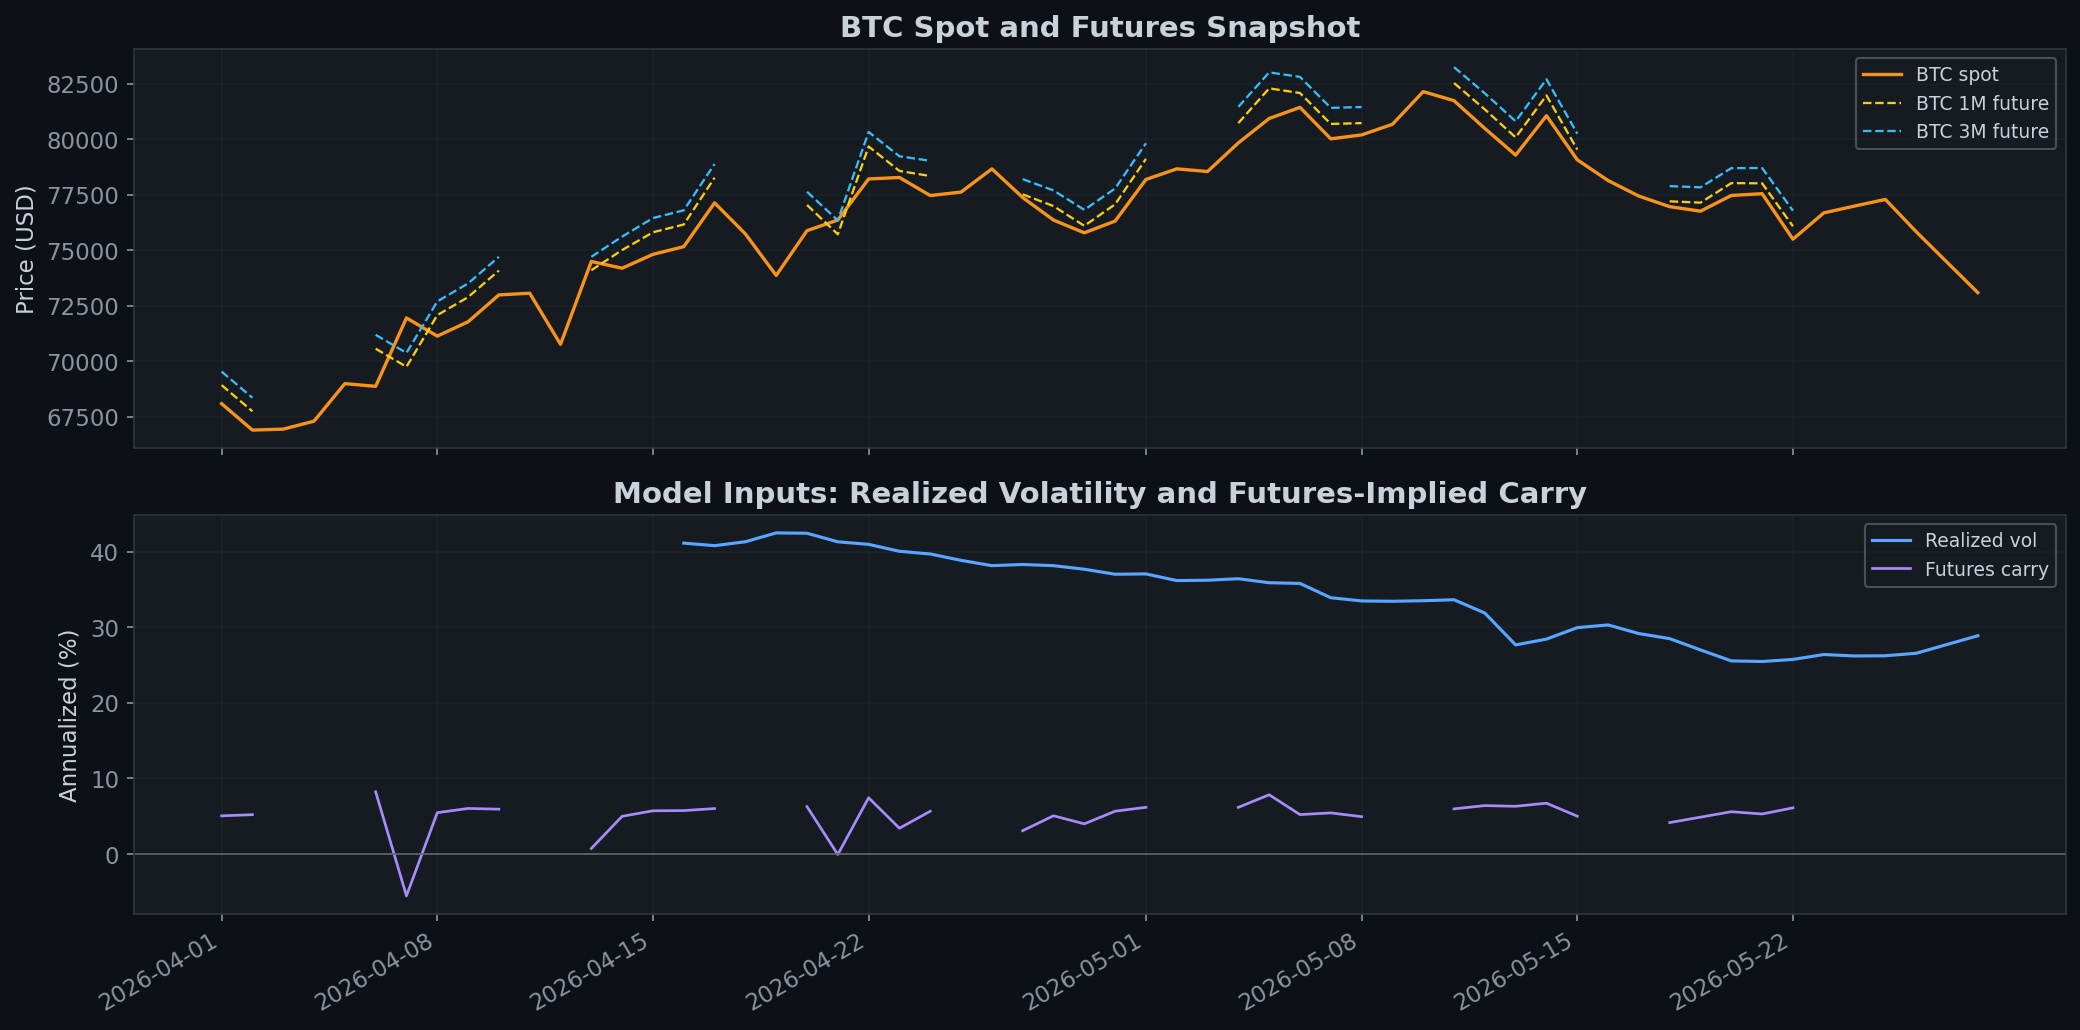

In [ ]:
if model_inputs.empty:
    _input_plot = mo.callout(mo.md("No BTC model inputs to plot."), kind="warn")
else:
    _fig_i, (_ax_p, _ax_v) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    _ax_p.plot(model_inputs.index, model_inputs["btc_spot"], color="#f7931a", lw=1.6, label="BTC spot")
    for _col, _color, _label in [
        ("btc_1m_future", "#facc15", "BTC 1M future"),
        ("btc_3m_future", "#38bdf8", "BTC 3M future"),
    ]:
        if _col in model_inputs:
            _ax_p.plot(model_inputs.index, model_inputs[_col], color=_color, lw=1.1, ls="--", label=_label)
    _ax_p.set_ylabel("Price (USD)")
    _ax_p.set_title("BTC Spot and Futures Snapshot")
    _ax_p.legend(fontsize=9, framealpha=0.3)

    if "realized_vol" in model_inputs:
        _ax_v.plot(model_inputs.index, model_inputs["realized_vol"] * 100, color="#58a6ff", lw=1.5, label="Realized vol")
    if "carry_rate" in model_inputs:
        _ax_v.plot(model_inputs.index, model_inputs["carry_rate"] * 100, color="#a78bfa", lw=1.3, label="Futures carry")
    _ax_v.axhline(0, color="#666", lw=0.8)
    _ax_v.set_ylabel("Annualized (%)")
    _ax_v.set_title("Model Inputs: Realized Volatility and Futures-Implied Carry")
    _ax_v.legend(fontsize=9, framealpha=0.3)

    _fig_i.autofmt_xdate()
    _fig_i.tight_layout()
    _input_plot = _fig_i
_input_plot

In [ ]:
if fair_history.empty or poly_prices.empty:
    latest_edges = pd.DataFrame()
    _edge_table = mo.callout(mo.md("No fair-value comparison available."), kind="warn")
else:
    _poly = poly_prices.rename(columns={"prob": "polymarket_prob"})
    _merged = fair_history.merge(_poly, on=["date", "slug"], how="inner")
    _merged = _merged.merge(
        markets[["slug", "question", "end_date", "liquidity", "volume"]],
        on="slug",
        how="left",
    )
    _merged["edge"] = _merged["fair_prob"] - _merged["polymarket_prob"]
    latest_edges = (
        _merged.sort_values("date")
        .groupby("slug", as_index=False)
        .tail(1)
        .sort_values("edge", ascending=False)
        .reset_index(drop=True)
    )
    _display = latest_edges[[
        "date",
        "label",
        "polymarket_prob",
        "fair_prob",
        "edge",
        "delta_pp_per_1pct_btc",
        "realized_vol",
        "carry_rate",
        "liquidity",
    ]].copy()
    for _col in ["polymarket_prob", "fair_prob", "edge", "realized_vol", "carry_rate"]:
        _display[_col] = (_display[_col] * 100).round(1)
    _display["delta_pp_per_1pct_btc"] = _display["delta_pp_per_1pct_btc"].round(2)
    _display = _display.rename(columns={
        "polymarket_prob": "pm_prob_pct",
        "fair_prob": "fair_prob_pct",
        "edge": "edge_pct_pts",
        "realized_vol": "vol_pct",
        "carry_rate": "carry_pct",
    })
    _edge_table = _display

_edge_table

,date,label,pm_prob_pct,fair_prob_pct,edge_pct_pts,delta_pp_per_1pct_btc,vol_pct,carry_pct,liquidity
0,2026-05-26,Reach $120k,15.5,2.9,-12.6,0.36,26.6,5.2,30721.9808
1,2026-05-26,Reach $110k,21.5,7.8,-13.7,0.81,26.6,5.2,37602.0970
2,2026-05-26,Reach $100k,36.0,19.2,-16.8,1.63,26.6,5.2,44847.4405
3,2026-05-26,Reach $90k,59.5,42.3,-17.2,2.75,26.6,5.2,45578.0300
4,2026-05-26,Dip to $50k,38.0,3.9,-34.1,-0.46,26.6,5.2,73957.6911


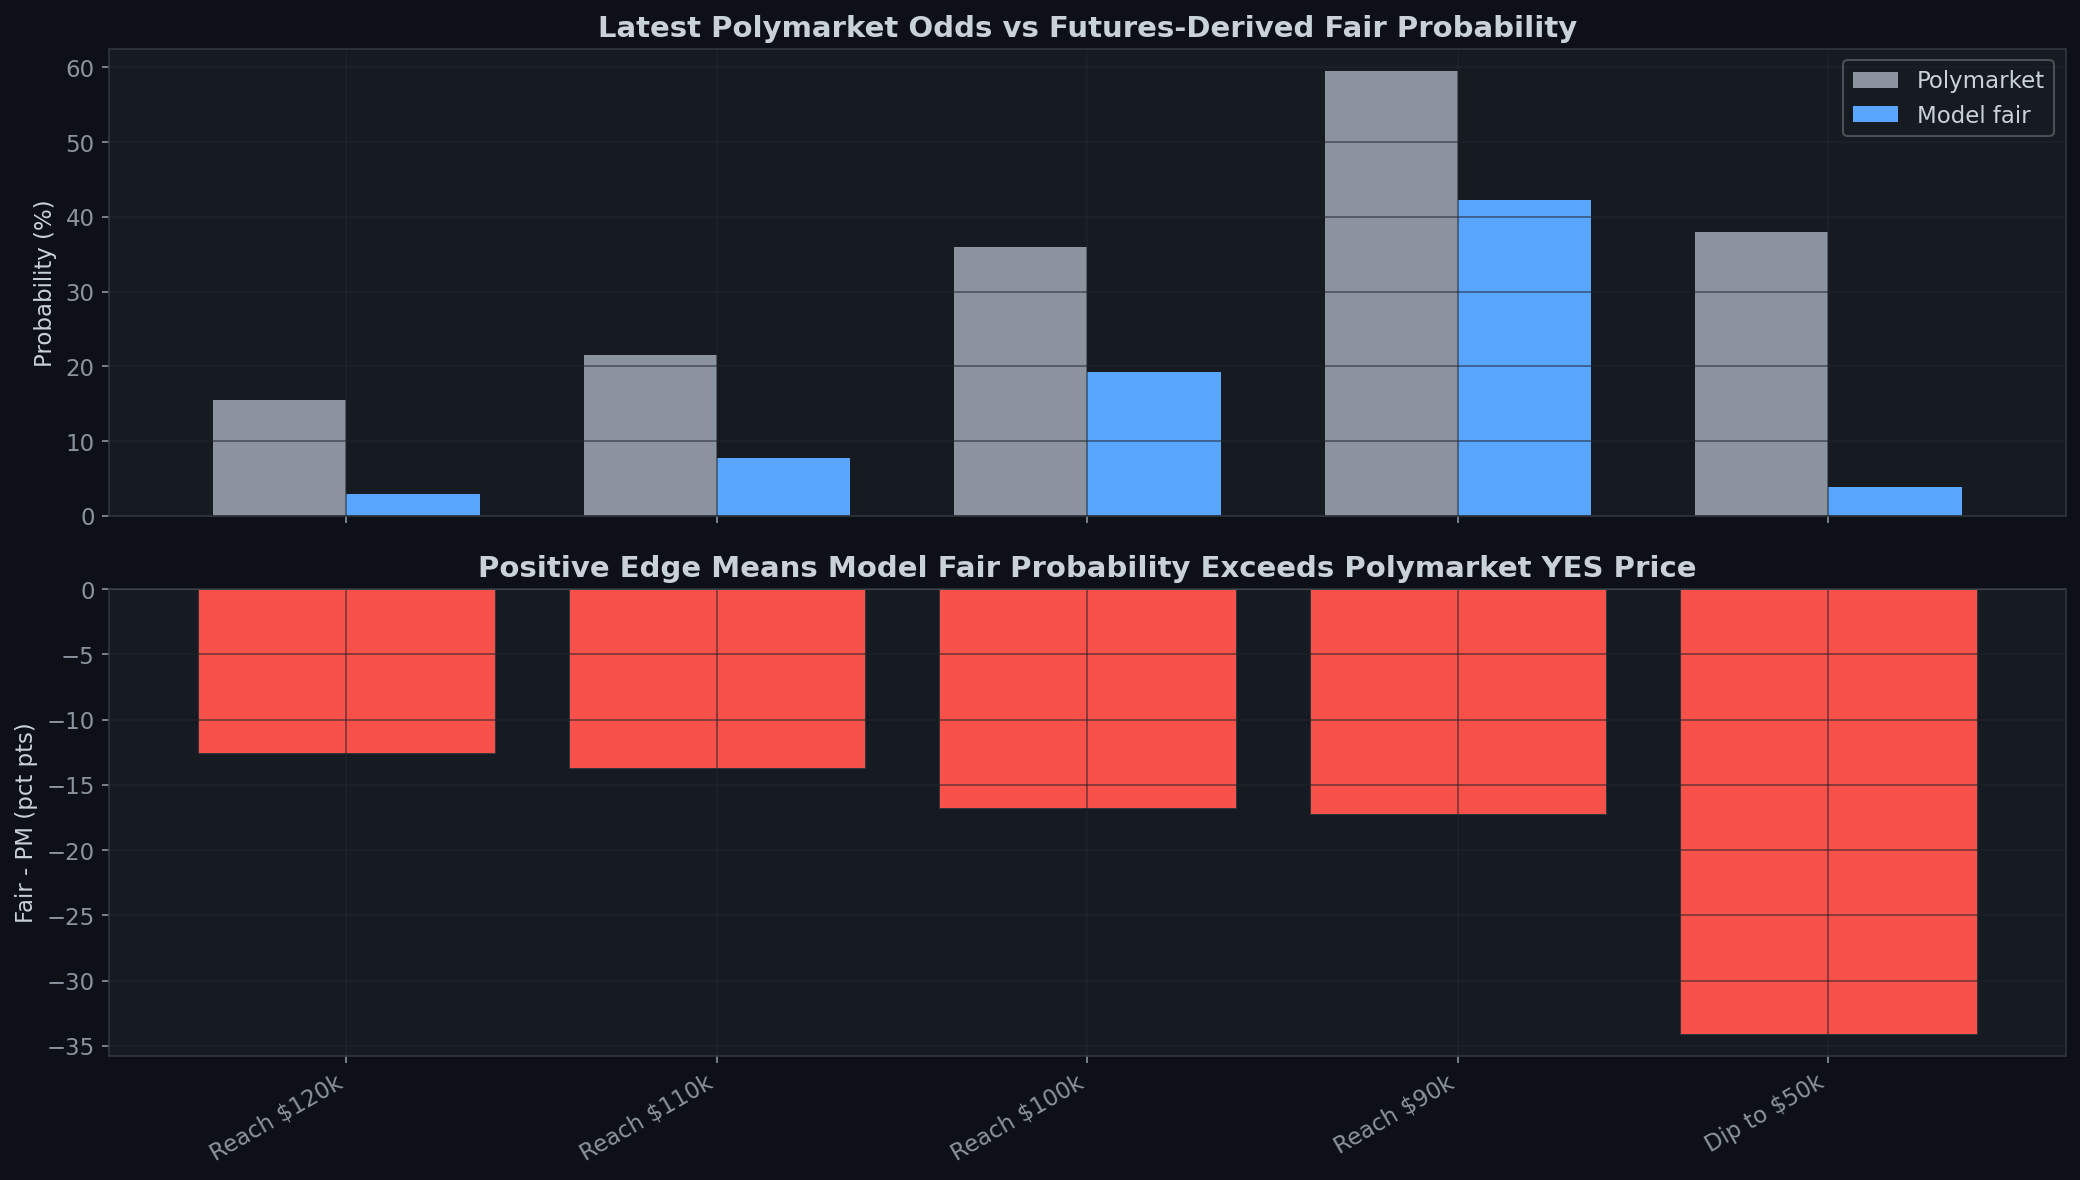

In [ ]:
if latest_edges.empty:
    _edge_plot = mo.callout(mo.md("No latest edge table to plot."), kind="warn")
else:
    _labels = latest_edges["label"].tolist()
    _x = np.arange(len(_labels))
    _w = 0.36

    _fig_e, (_ax_e1, _ax_e2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    _ax_e1.bar(_x - _w / 2, latest_edges["polymarket_prob"] * 100, width=_w, color="#8b949e", label="Polymarket")
    _ax_e1.bar(_x + _w / 2, latest_edges["fair_prob"] * 100, width=_w, color="#58a6ff", label="Model fair")
    _ax_e1.set_ylabel("Probability (%)")
    _ax_e1.set_title("Latest Polymarket Odds vs Futures-Derived Fair Probability")
    _ax_e1.legend(framealpha=0.3)

    _edge_pct = latest_edges["edge"] * 100
    _colors = np.where(_edge_pct >= 0, "#3fb950", "#f85149")
    _ax_e2.bar(_x, _edge_pct, color=_colors, edgecolor="#30363d", linewidth=0.5)
    _ax_e2.axhline(0, color="#8b949e", lw=0.9)
    _ax_e2.set_ylabel("Fair - PM (pct pts)")
    _ax_e2.set_title("Positive Edge Means Model Fair Probability Exceeds Polymarket YES Price")
    _ax_e2.set_xticks(_x)
    _ax_e2.set_xticklabels(_labels, rotation=30, ha="right")

    _fig_e.tight_layout()
    _edge_plot = _fig_e
_edge_plot

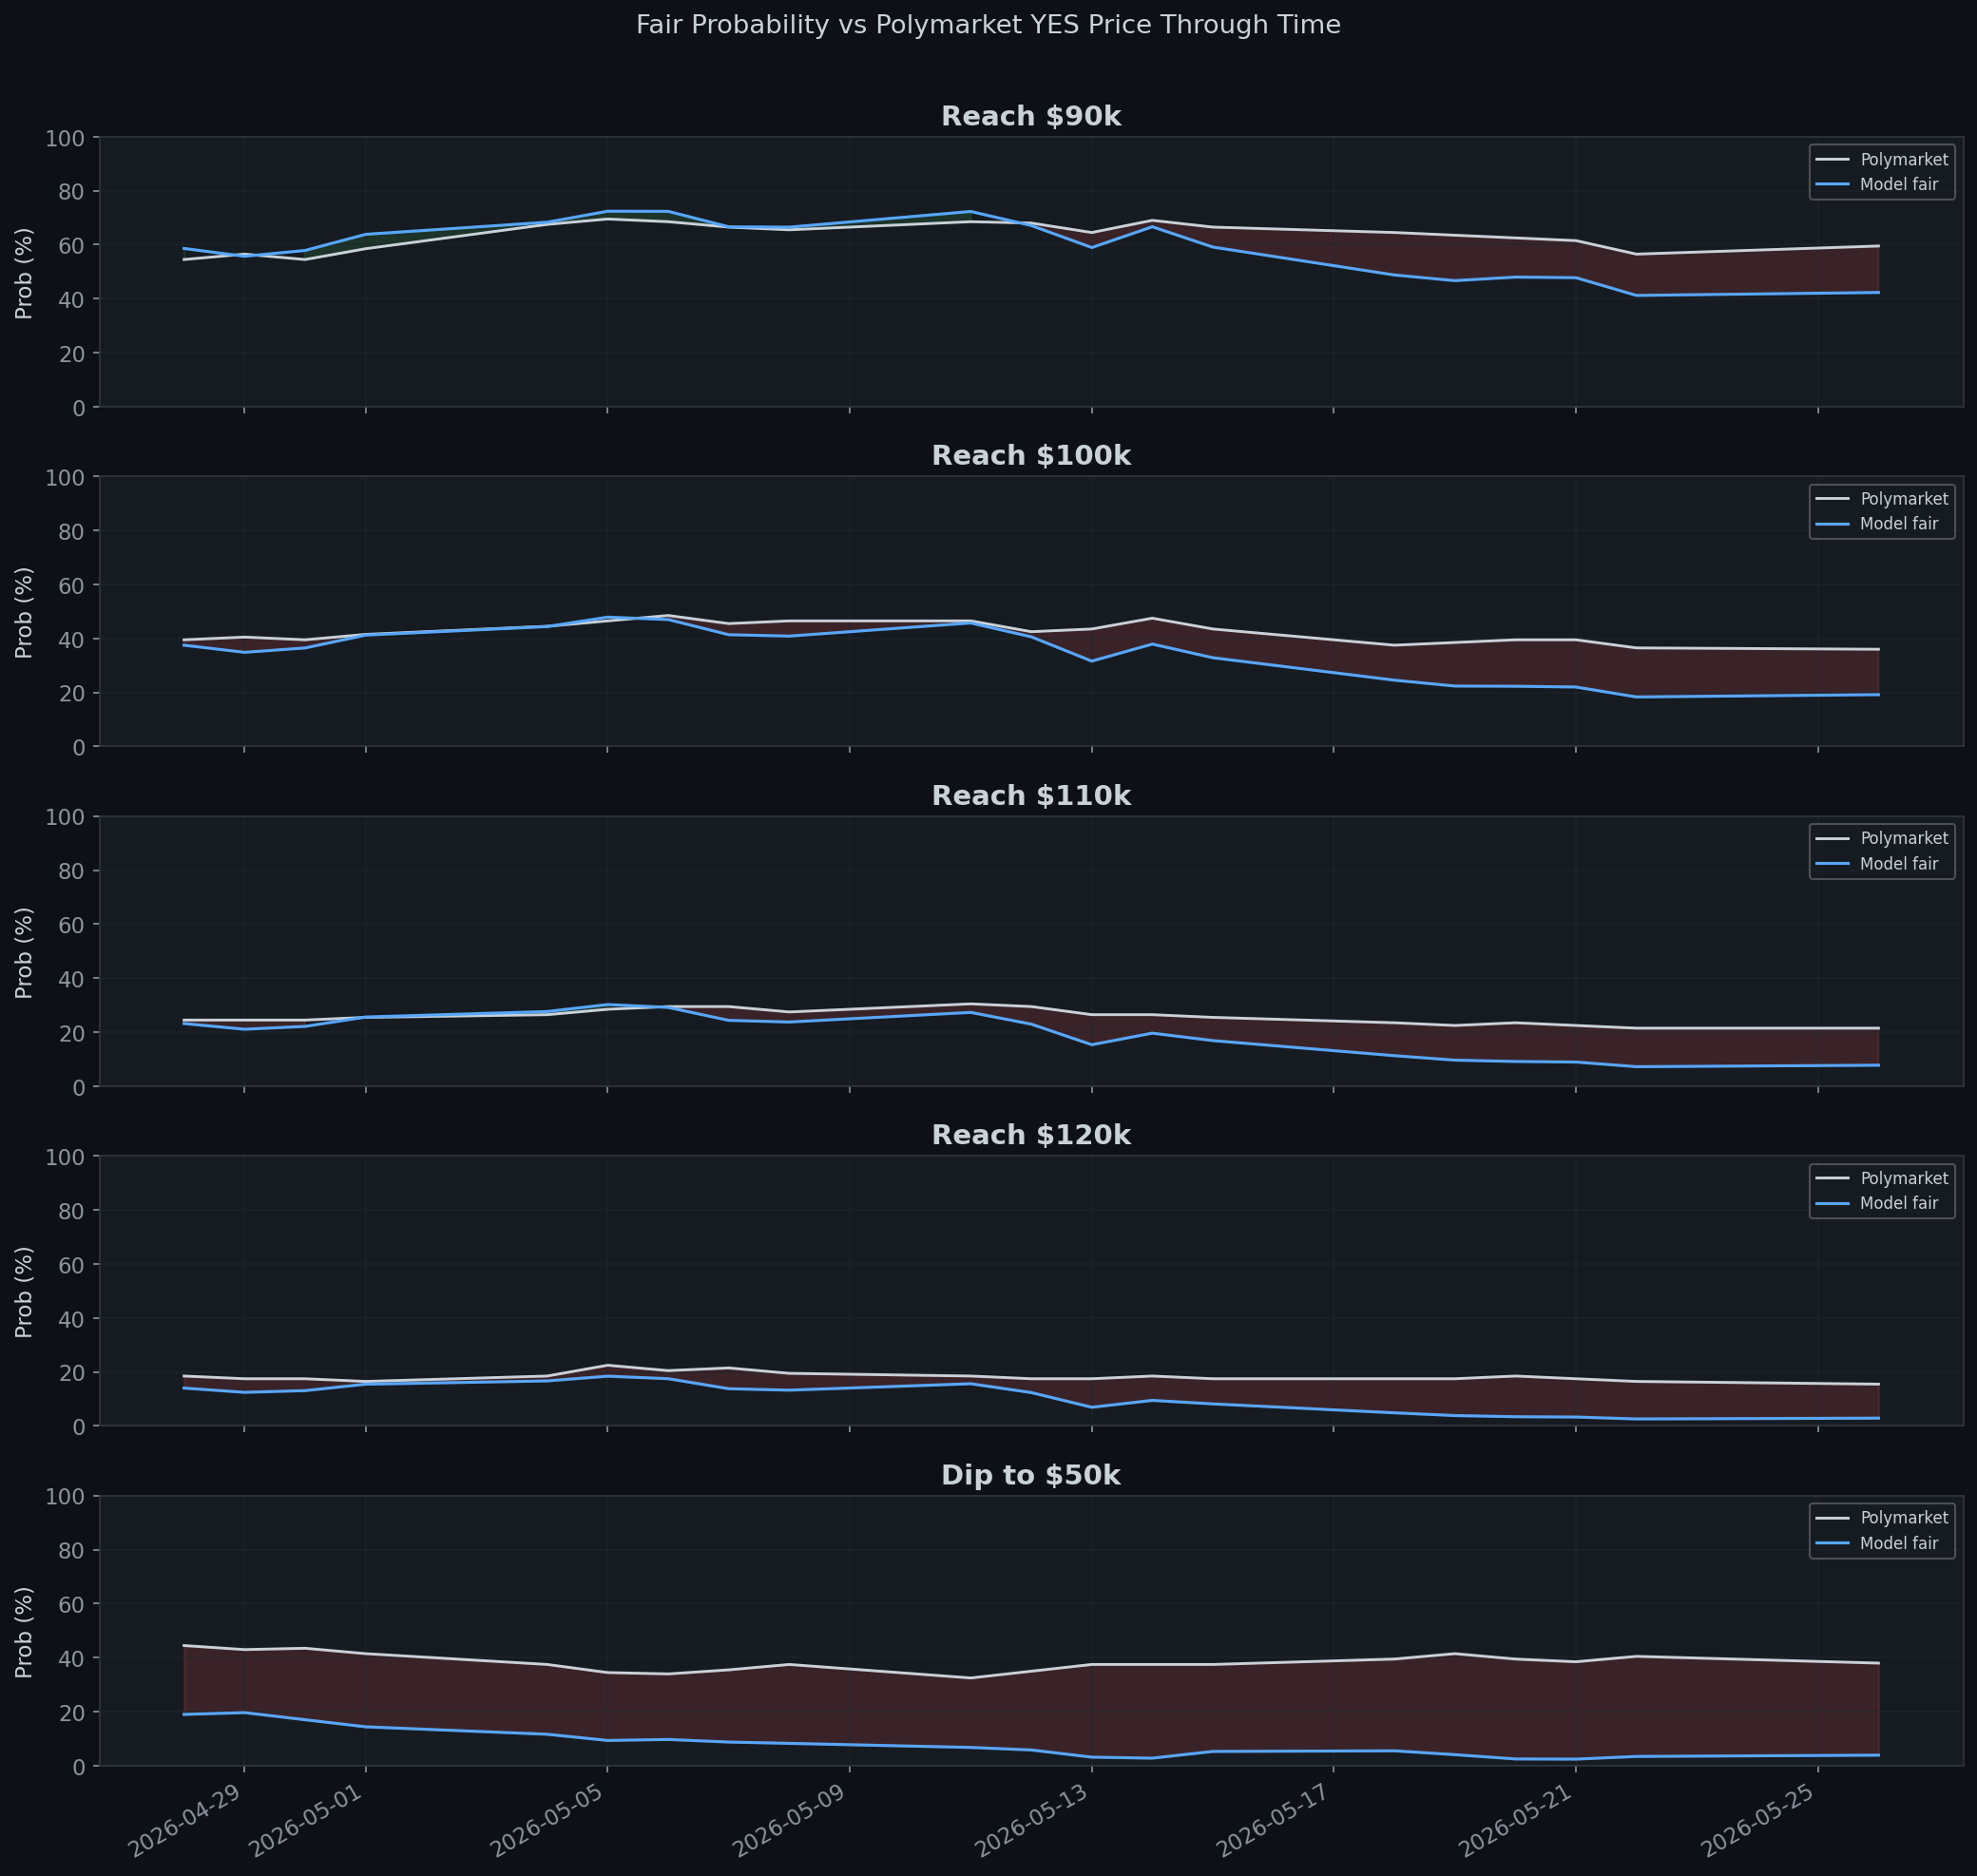

In [ ]:
if fair_history.empty or poly_prices.empty:
    _history_plot = mo.callout(mo.md("No fair-value history to plot."), kind="warn")
else:
    _poly = poly_prices.rename(columns={"prob": "polymarket_prob"})
    _merged = fair_history.merge(_poly, on=["date", "slug"], how="inner")
    _markets = _merged["label"].drop_duplicates().tolist()
    _fig_h, _axes_h = plt.subplots(len(_markets), 1, figsize=(14, max(8, 2.6 * len(_markets))), sharex=True)
    if len(_markets) == 1:
        _axes_h = [_axes_h]

    for _ax_h, _label_h in zip(_axes_h, _markets):
        _d = _merged[_merged["label"] == _label_h].sort_values("date")
        _ax_h.plot(_d["date"], _d["polymarket_prob"] * 100, color="#c9d1d9", lw=1.4, label="Polymarket")
        _ax_h.plot(_d["date"], _d["fair_prob"] * 100, color="#58a6ff", lw=1.5, label="Model fair")
        _ax_h.fill_between(
            pd.to_datetime(_d["date"]),
            _d["polymarket_prob"] * 100,
            _d["fair_prob"] * 100,
            where=(_d["fair_prob"] >= _d["polymarket_prob"]),
            color="#3fb950",
            alpha=0.16,
        )
        _ax_h.fill_between(
            pd.to_datetime(_d["date"]),
            _d["polymarket_prob"] * 100,
            _d["fair_prob"] * 100,
            where=(_d["fair_prob"] < _d["polymarket_prob"]),
            color="#f85149",
            alpha=0.16,
        )
        _ax_h.set_ylim(0, 100)
        _ax_h.set_ylabel("Prob (%)")
        _ax_h.set_title(_label_h)
        _ax_h.legend(fontsize=8, framealpha=0.3, loc="best")

    _fig_h.suptitle("Fair Probability vs Polymarket YES Price Through Time", y=1.01)
    _fig_h.autofmt_xdate()
    _fig_h.tight_layout()
    _history_plot = _fig_h
_history_plot

## How To Read The Output

- **Fair probability** is the model-implied probability of touching the target before the market end date.
- **Edge** is `fair probability - Polymarket YES price`.
- Positive edge means the model says YES is cheap; negative edge means YES is rich.
- The hedge column is the model probability change, in percentage points, for a 1% BTC spot move.

The model is intentionally simple: futures set the drift/carry, trailing BTC
realized volatility sets the path dispersion, and a GBM barrier formula
converts those inputs into touch probabilities.